In [82]:
#Required Libaries
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pandas as pd

In [83]:
def TestCorrectness(arr):
    buffer_array = arr
    buffer_array.sort()
    return buffer_array == arr

In [84]:
#Creates an array of size n
def createArray(n):
    return list(np.random.randint(100, size = n))

def createTestData():
    testData = []
    
    for i in range(0, 100):
        # testData.append(createArray(i)) #this is an issue, because the n arg is the number of elements in the array and it inc by 1 every loop
        testData.append(createArray(1))
    return testData

In [85]:
def addDatatoDoc(testD):
    # f1 = open("deb_data.txt", "w")
    # f1.write
    np.savetxt("deb_data3.txt", testD, fmt= '%1.f')

In [86]:
#Insert sort implementation
def InsertionSort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i-1
        #If the checkeed element is greater than the key then we move those array elements to one position ahead
        while j>=0 and key<arr[j]: 
            arr[j+1] = arr[j]
            j -= 1
        arr[j+1] = key
    return arr

def TimeInsertionSort(arr):
    start = time.perf_counter()
    InsertionSort(arr)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [87]:
#Quick sort Implementation
def swap(arr, i, j):
    arr[i], arr[j] = arr[j], arr[i]

def partition(arr, low, high):
    # Choosing the piviot 
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            swap(arr, i, j)
    swap(arr, i + 1, high)
    return i + 1

def QuickSort(arr, low, high):
    if low < high:
        pi = partition(arr, low, high)
        QuickSort(arr, low, pi - 1)
        QuickSort(arr, pi + 1, high)

def TimeQuickSort(arr):
    start = time.perf_counter()
    QuickSort(arr, 0, len(arr) -1)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [88]:
def TestCorrectness(arr):
    buffer_array = arr
    buffer_array.sort()
    return arr == buffer_array

In [ ]:
#Needs to make sure the size N is in the Y axis
def main():
    testData = createTestData()
    # addDatatoDoc(testData)
    insertionData = []
    quickData = []
    testDataLength = []
    #Collecting data for the time it takes to perform quick sort and insertion sort on the arrays created of different sizes.
    for testArray in testData:
        testDataLength.append(len(testArray))
        #We pass copies of the array so that each algorithm deals with the original unsorted array
        quickData.append(TimeQuickSort(testArray.copy()))
        insertionData.append(TimeInsertionSort(testArray.copy()))
    #If there is a -1 in the data, that means that the data for insertion or quick sort failed to pass the correctness test
    if(-1 in insertionData or -1 in quickData):
        print("One of the arrays were not sorted correctly.")
        return 1
    fig = plt.figure()
    fig, ax = plt.subplots(layout = "constrained")
    testDataLength = np.array(testDataLength)
    a, b = np.polyfit(testDataLength, insertionData, 1) # look at this laater
    c, d = np.polyfit(testDataLength, quickData, 1)
    # plt.scatter(testDataLength, insertionData)
    # plt.scatter(testDataLength, quickData)
    plt.plot(testDataLength, a*testDataLength+b, label = "Insertion Sort")
    ax.plot(testDataLength, c*testDataLength+d, label = "Quick Sort")
    ax.set_title("Time to sort vs Size of array")
    ax.set_ylabel("Time")
    ax.set_xlabel("Size of array")
    ax.legend()

C:\Users\debor\AppData\Local\Temp\ipykernel_14636\2105866682.py:21: RankWarning: Polyfit may be poorly conditioned
  a, b = np.polyfit(testDataLength, insertionData, 1) # look at this laater
C:\Users\debor\AppData\Local\Temp\ipykernel_14636\2105866682.py:22: RankWarning: Polyfit may be poorly conditioned
  c, d = np.polyfit(testDataLength, quickData, 1)


<Figure size 640x480 with 0 Axes>

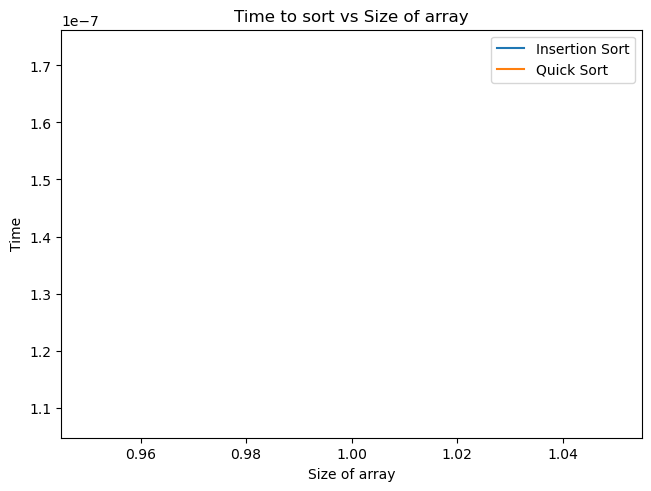

In [90]:
main()